### Chapter 0: Setup
Importing all necessary packages and initializing the classes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.sandbox.tsa.try_var_convolve import a2n3inv

from spintronics import SpintronicCircuit
Setup=SpintronicCircuit()

[[ 20.  20.  20.]
 [ 42.  42.  42.]
 [ 46.  46.  46.]
 [ 50.  50.  50.]
 [ 54.  54.  54.]
 [ 58.  58.  58.]
 [ 62.  62.  62.]
 [ 66.  66.  66.]
 [ 70.  70.  70.]
 [ 74.  74.  74.]
 [ 78.  78.  78.]
 [ 82.  82.  82.]
 [ 86.  86.  86.]
 [ 90.  90.  90.]
 [ 94.  94.  94.]
 [ 98.  98.  98.]
 [102. 102. 102.]
 [106. 106. 106.]
 [110. 110. 110.]
 [114. 114. 114.]]
[[  1.  41.  81.]
 [  3.  43.  83.]
 [  5.  45.  85.]
 [  7.  47.  87.]
 [  9.  49.  89.]
 [ 11.  51.  91.]
 [ 13.  53.  93.]
 [ 15.  55.  95.]
 [ 17.  57.  97.]
 [ 19.  59.  99.]
 [ 21.  61. 101.]
 [ 23.  63. 103.]
 [ 25.  65. 105.]
 [ 27.  67. 107.]
 [ 29.  69. 109.]
 [ 31.  71. 111.]
 [ 33.  73. 113.]
 [ 35.  75. 115.]
 [ 37.  77. 117.]] [[  1  41  81]
 [  3  43  83]
 [  5  45  85]
 [  7  47  87]
 [  9  49  89]
 [ 11  51  91]
 [ 13  53  93]
 [ 15  55  95]
 [ 17  57  97]
 [ 19  59  99]
 [ 21  61 101]
 [ 23  63 103]
 [ 25  65 105]
 [ 27  67 107]
 [ 29  69 109]
 [ 31  71 111]
 [ 33  73 113]
 [ 35  75 115]
 [ 37  77 117]]
True


AttributeError: module 'numpy' has no attribute 'complex'.
`np.complex` was a deprecated alias for the builtin `complex`. To avoid this error in existing code, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

### Chapter 1:
Solve #task 4a, derive the analytic ...

In [2]:
def setup0():
    # First the Normal terminals
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")

    # Adding ferro terminals
    Setup.addFerroTerminal("F1",magnetization=[1.0,0,0])
    Setup.addFerroTerminal("F2",magnetization=[0,1.0,0])
    Setup.addFerroTerminal("F3",magnetization=[0,0,1.0])

    # Add the normal nodes, no Ferromagnetic elements yet.
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")


    #Define the params
    P = 0
    Gr1 = 0
    Gr2 = 0
    Pap = 0

    Gn = 1.0 #For normal connectors
    GFN=[1.0,0.9,0.5,0.5]
    # Now the normal connectors, treated as Ohmic conductors
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    # The F-N connectors
    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)


In [3]:
setup0()
Setup.finalize()
print("Conductance matrix: ", Setup.ConductanceMatrix)

Conductance matrix:  [[-0.55365285  0.07551021  0.30472572  0.12701732  0.0463996 ]
 [ 0.07185401 -0.55365285  0.05368877  0.12340758  0.30470249]
 [ 0.30470249  0.0463996  -0.475281    0.08285415  0.04132477]
 [ 0.12340758  0.12701732  0.09007363 -0.42335268  0.08285415]
 [ 0.05368877  0.30472572  0.02679289  0.09007363 -0.475281  ]]


### AHE


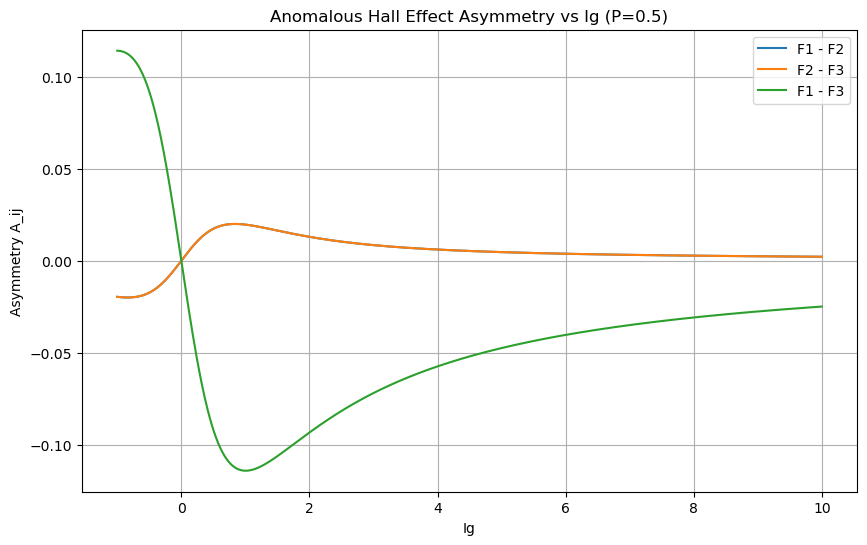

In [14]:
import numpy as np
import matplotlib.pyplot as plt
def compute_AHE(P_val):
    #Reset entire build
    global Setup
    from spintronics import SpintronicCircuit
    Setup = SpintronicCircuit()
    setup0()
    Setup.finalize()

        #setting magnetization of the nodes
    Setup.setMagnetization('F1', 'T', [-1.0,0,0])
    Setup.setMagnetization('F2', 'T', [0,-1.0,0])
    Setup.setMagnetization('F3', 'T', [0,0,-1.0])

    G = 1.0
    Ig_values = np.linspace(-1,10,1000)
    # First setup magnetizations
    A_12, A_23, A_13 = [], [], []
    for Ig in Ig_values:
        pars = [G, P_val, 0.0, Ig]
        Setup.setConductance('CF1',pars)
        Setup.setConductance('CF2',pars)
        Setup.setConductance('CF3',pars)

        Setup.compute()
        G_mat = Setup.ConductanceMatrix

        #Assymetries
        a12 = (G_mat[2,3] - G_mat[3,2]) / (G_mat[2,3] + G_mat[3,2])
        a23 = (G_mat[3,4] - G_mat[4,3]) / (G_mat[3,4] + G_mat[4,3])
        a13 = (G_mat[2,4] - G_mat[4,2]) / (G_mat[2,4] + G_mat[4,2])

        A_12.append(a12)
        A_23.append(a23)
        A_13.append(a13)
    return Ig_values, np.array(A_12), np.array(A_23), np.array(A_13)

Ig_vals, A12, A23, A13 = compute_AHE(P_val=0.5)
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(Ig_vals, A12, label='F1 - F2')
plt.plot(Ig_vals, A23, label='F2 - F3')
plt.plot(Ig_vals, A13, label='F1 - F3')
plt.xlabel('Ig')
plt.ylabel('Asymmetry A_ij')
plt.title('Anomalous Hall Effect Asymmetry vs Ig (P=0.5)')
plt.legend()
plt.grid(True)
plt.show()



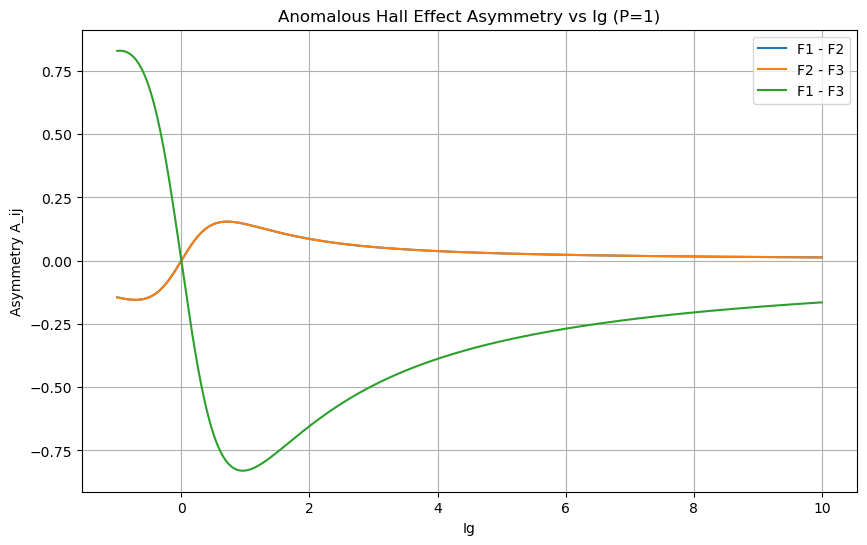

In [15]:
Ig_vals, A12, A23, A13 = compute_AHE(P_val=1.0)
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(Ig_vals, A12, label='F1 - F2')
plt.plot(Ig_vals, A23, label='F2 - F3')
plt.plot(Ig_vals, A13, label='F1 - F3')
plt.xlabel('Ig')
plt.ylabel('Asymmetry A_ij')
plt.title('Anomalous Hall Effect Asymmetry vs Ig (P=1)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_asymmetry(G_mat):
    """Helper function to safely compute the AHE asymmetry matrix."""
    # A_ij = (G_ij - G_ji) / (G_ij + G_ji)
    A = np.zeros((5,5))
    for i in range(5):
        for j in range(5):
            denom = G_mat[i,j] + G_mat[j,i]
            if denom != 0:
                A[i,j] = (G_mat[i,j] - G_mat[j,i]) / denom
    # Return specific terminal pairs: F1-F2 (2,3), F2-F3 (3,4), F1-F3 (2,4)
    return A[2,3], A[3,4], A[2,4]

def generate_parameter_plots():
    # 1. Setup the static topology (assuming setup_topology() from earlier is run)
    setup_topology()

    # Define our sweep arrays
    Ig_array = np.linspace(-5, 5, 50)
    theta_array = np.linspace(0, np.pi, 50)

    # Prepare the figure grid
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Anomalous Hall Effect Parameter Space Analysis', fontsize=16)

    #PLOT 1: Asymmetry vs Ig for P = 0.5
    Setup.setMagnetization('F1', 'T', [1, 0, 0])
    Setup.setMagnetization('F2', 'T', [0, 1, 0])
    Setup.setMagnetization('F3', 'T', [0, 0, 1])

    A12_list, A23_list, A13_list = [], [], []
    for ig in Ig_array:
        Setup.setConductance('CF1', [1.0, 0.5, 0.0, ig])
        Setup.setConductance('CF2', [1.0, 0.5, 0.0, ig])
        Setup.setConductance('CF3', [1.0, 0.5, 0.0, ig])
        Setup.compute()
        a12, a23, a13 = compute_asymmetry(Setup.ConductanceMatrix)
        A12_list.append(a12); A23_list.append(a23); A13_list.append(a13)

    axs[0, 0].plot(Ig_array, A12_list, label='A12 (F1-F2)')
    axs[0, 0].plot(Ig_array, A23_list, label='A23 (F2-F3)')
    axs[0, 0].plot(Ig_array, A13_list, label='A13 (F1-F3)')
    axs[0, 0].set_title('Sweep Ig (P=0.5, Orthogonal M)')
    axs[0, 0].set_xlabel('Mixing Conductance (Ig)')
    axs[0, 0].set_ylabel('Asymmetry')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Asymmetry vs Ig for P = 1.0
    A12_list_P1 = []
    for ig in Ig_array:
        Setup.setConductance('CF1', [1.0, 1.0, 0.0, ig])
        Setup.setConductance('CF2', [1.0, 1.0, 0.0, ig])
        Setup.setConductance('CF3', [1.0, 1.0, 0.0, ig])
        Setup.compute()
        a12, _, _ = compute_asymmetry(Setup.ConductanceMatrix)
        A12_list_P1.append(a12)

    axs[0, 1].plot(Ig_array, A12_list, label='P=0.5', linestyle='--')
    axs[0, 1].plot(Ig_array, A12_list_P1, label='P=1.0 (Half Metal)')
    axs[0, 1].set_title('Comparison of Polarization (A12 only)')
    axs[0, 1].set_xlabel('Mixing Conductance (Ig)')
    axs[0, 1].set_ylabel('Asymmetry A12')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Asymmetry vs Theta
    # Fix Ig to peak value
    Setup.setConductance('CF1', [1.0, 0.5, 0.0, 1.0])
    Setup.setConductance('CF2', [1.0, 0.5, 0.0, 1.0])
    Setup.setConductance('CF3', [1.0, 0.5, 0.0, 1.0])

    phi = np.pi / 2
    psi = np.pi / 2
    A12_theta = []

    for th in theta_array:
        M1 = [np.sin(phi/2), 0, np.cos(phi/2)]
        M2 = [np.sin(psi)*np.sin(th), np.cos(psi)*np.sin(th), np.cos(th)]
        M3 = [-np.sin(phi/2), 0, np.cos(phi/2)]

        Setup.setMagnetization('F1', 'T', M1)
        Setup.setMagnetization('F2', 'T', M2)
        Setup.setMagnetization('F3', 'T', M3)
        Setup.compute()

        a12, _, _ = compute_asymmetry(Setup.ConductanceMatrix)
        A12_theta.append(a12)

    axs[1, 0].plot(np.degrees(theta_array), A12_theta, color='purple')
    axs[1, 0].set_title('Sweep Theta (Ig=1.0, P=0.5)')
    axs[1, 0].set_xlabel('Theta (Degrees)')
    axs[1, 0].set_ylabel('Asymmetry A12')
    axs[1, 0].grid(True)

    # Phase Space (A12 vs A23)
    # This plots how two asymmetries evolve together as Ig changes
    axs[1, 1].plot(A12_list, A23_list, marker='o', markersize=3, linestyle='-', alpha=0.7)
    axs[1, 1].set_title('Phase Space: A12 vs A23 (Sweeping Ig)')
    axs[1, 1].set_xlabel('A12 (F1-F2)')
    axs[1, 1].set_ylabel('A23 (F2-F3)')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

generate_parameter_plots()

### Exercise 4c - Magnetic dependence

In [24]:
def setup_topology():
    # First the Normal terminals
    global Setup
    from spintronics import SpintronicCircuit
    Setup = SpintronicCircuit()
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")

    # Adding ferro terminals
    Setup.addFerroTerminal("F1",magnetization=M1)
    Setup.addFerroTerminal("F2",magnetization=M2)
    Setup.addFerroTerminal("F3",magnetization=M3)

    # Add the normal nodes, no Ferromagnetic elements yet.
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")


    #Define the params
    Gf = 0.5
    P = 1.0
    Rg = 0
    Ig = 1.0
    Gn = 1.0 #For normal connectors
    GFN=[Gf,P,Rg,Ig]
    # Now the normal connectors, treated as Ohmic conductors
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    # The F-N connectors
    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)

    Setup.finalize()

setup_topology()

#Randomly chosen params below
phi  = 0
psi = np.pi /2
theta  = np.pi /4
M1 = [np.sin(phi/2), 0, np.cos(phi/2)]
M2 = [np.sin(psi)*np.sin(theta), np.cos(psi)*np.sin(theta), np.cos(theta)]
M3 = [-np.sin(phi/2), 0, np.cos(phi/2)]

#Setting the magnetization
Setup.setMagnetization('F1', 'T', M1)
Setup.setMagnetization('F2', 'T', M2)
Setup.setMagnetization('F3', 'T', M3)

Setup.compute

<bound method LinGenCircuit.compute of <spintronics.SpintronicCircuit object at 0x0000013CB73F3050>>

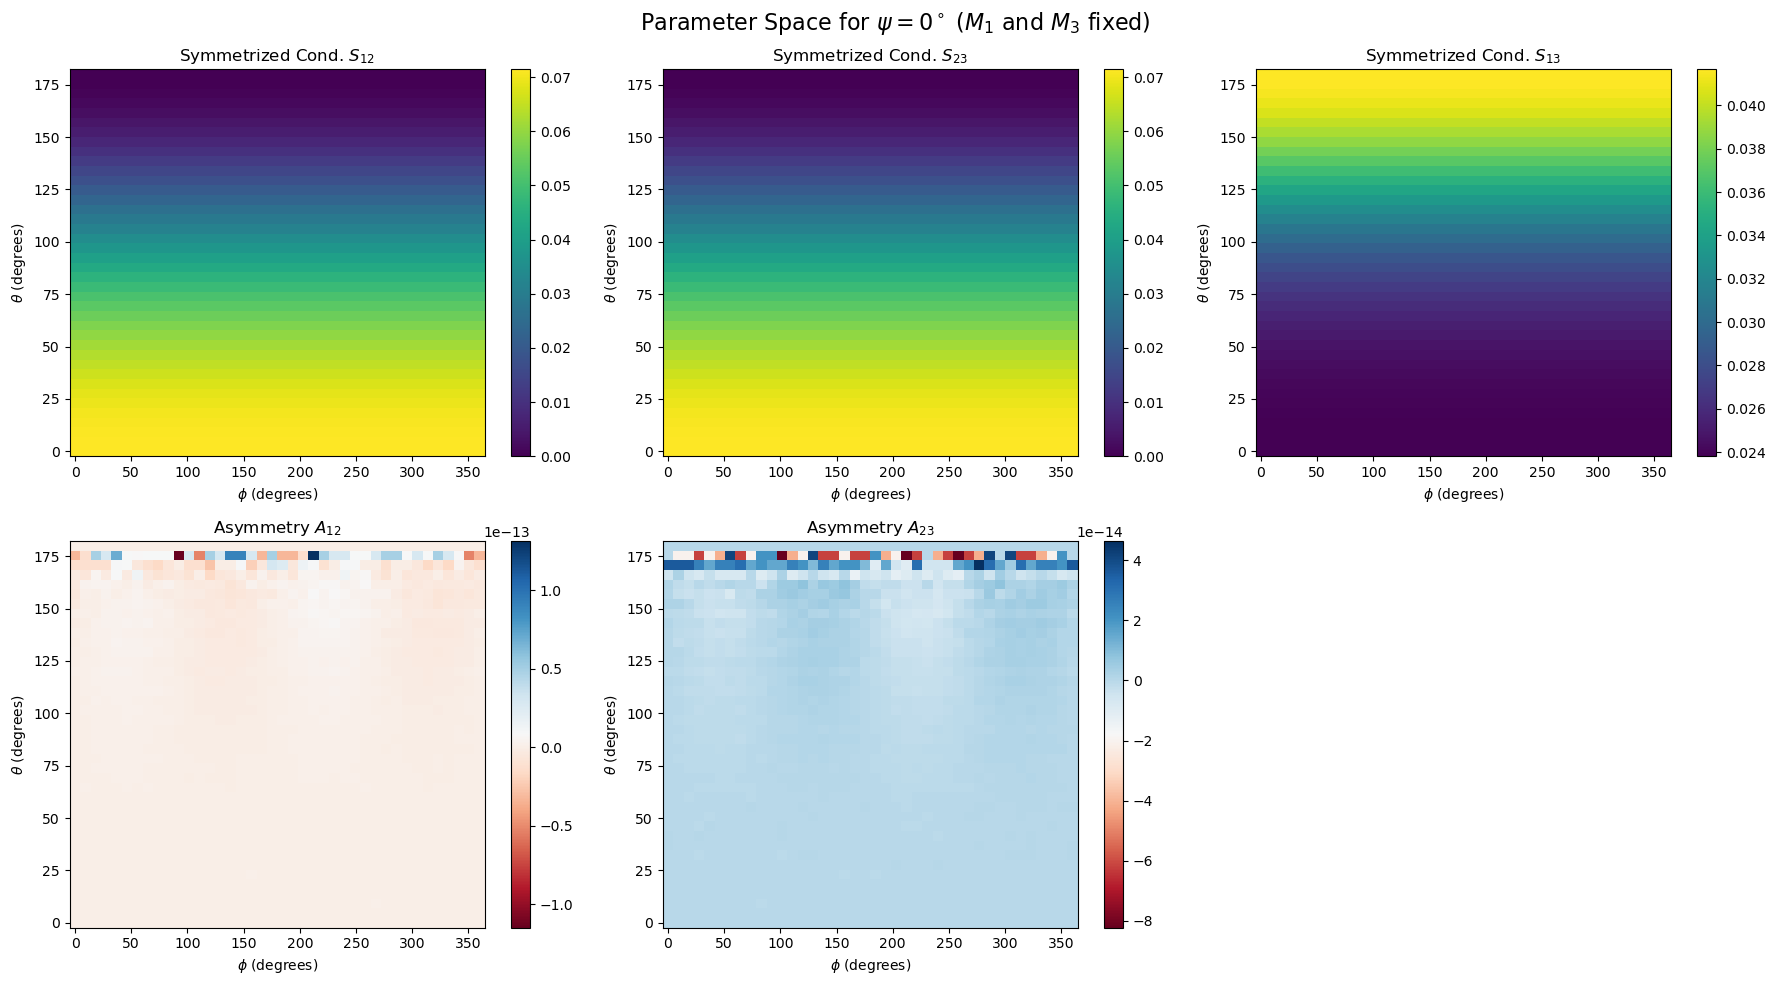

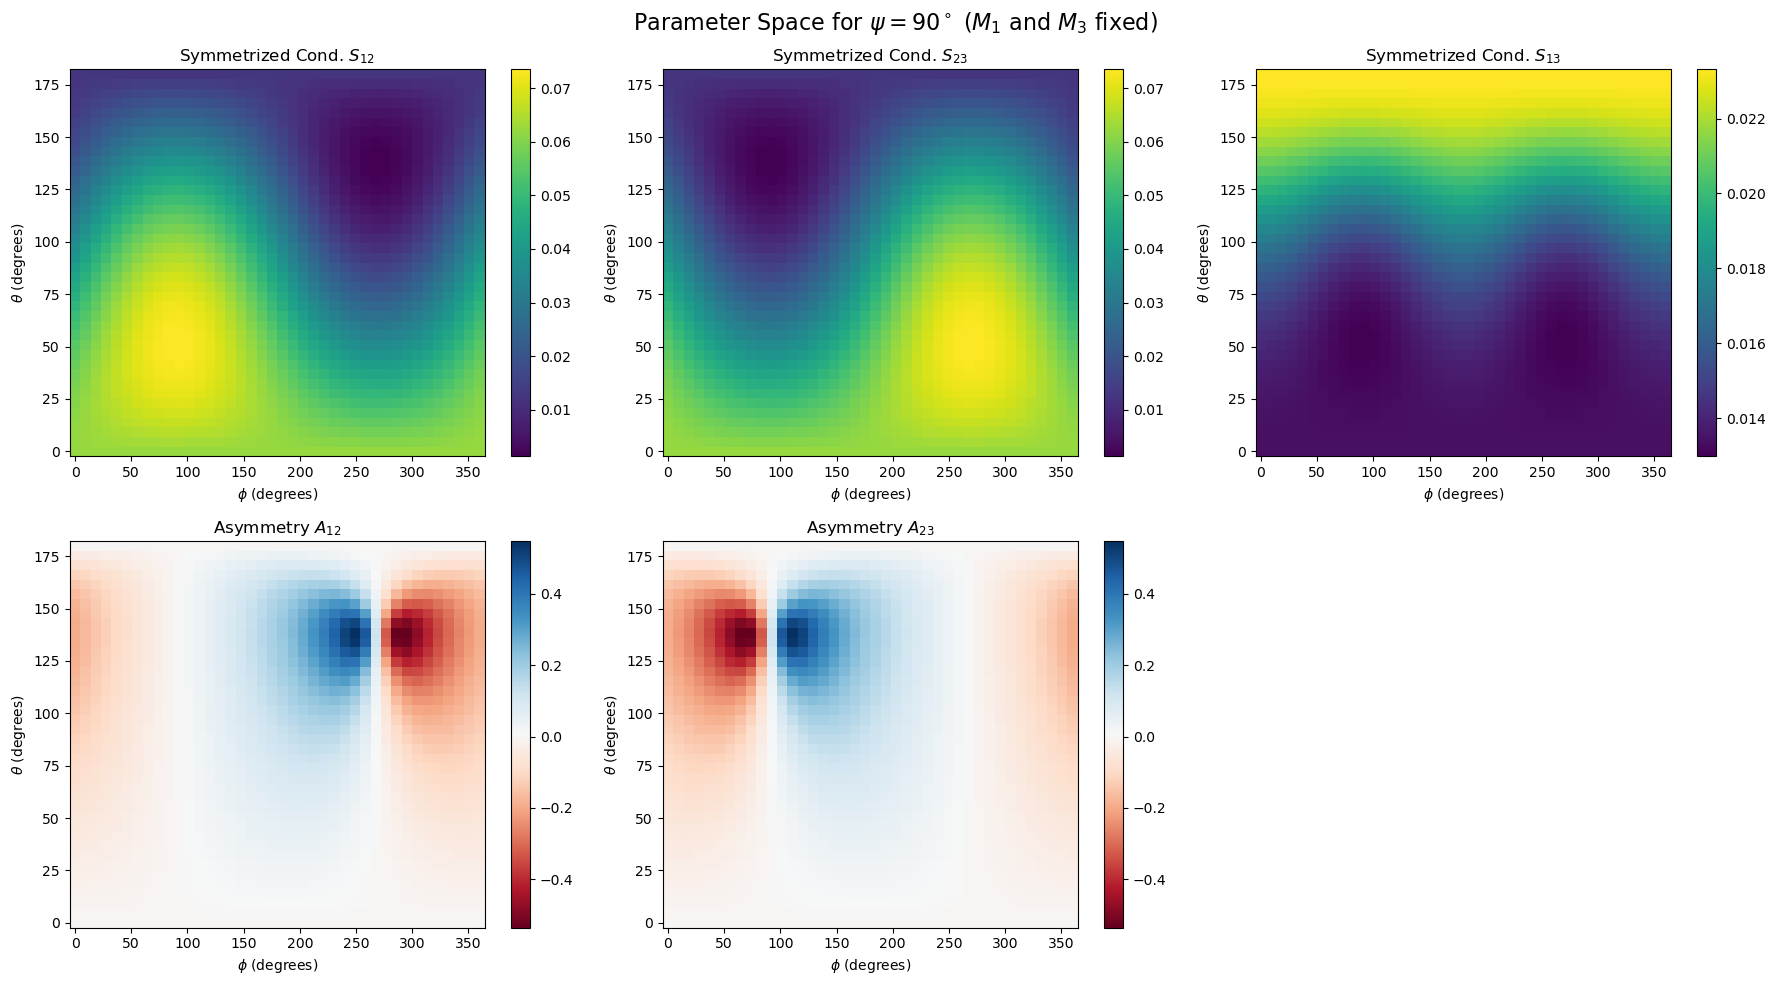

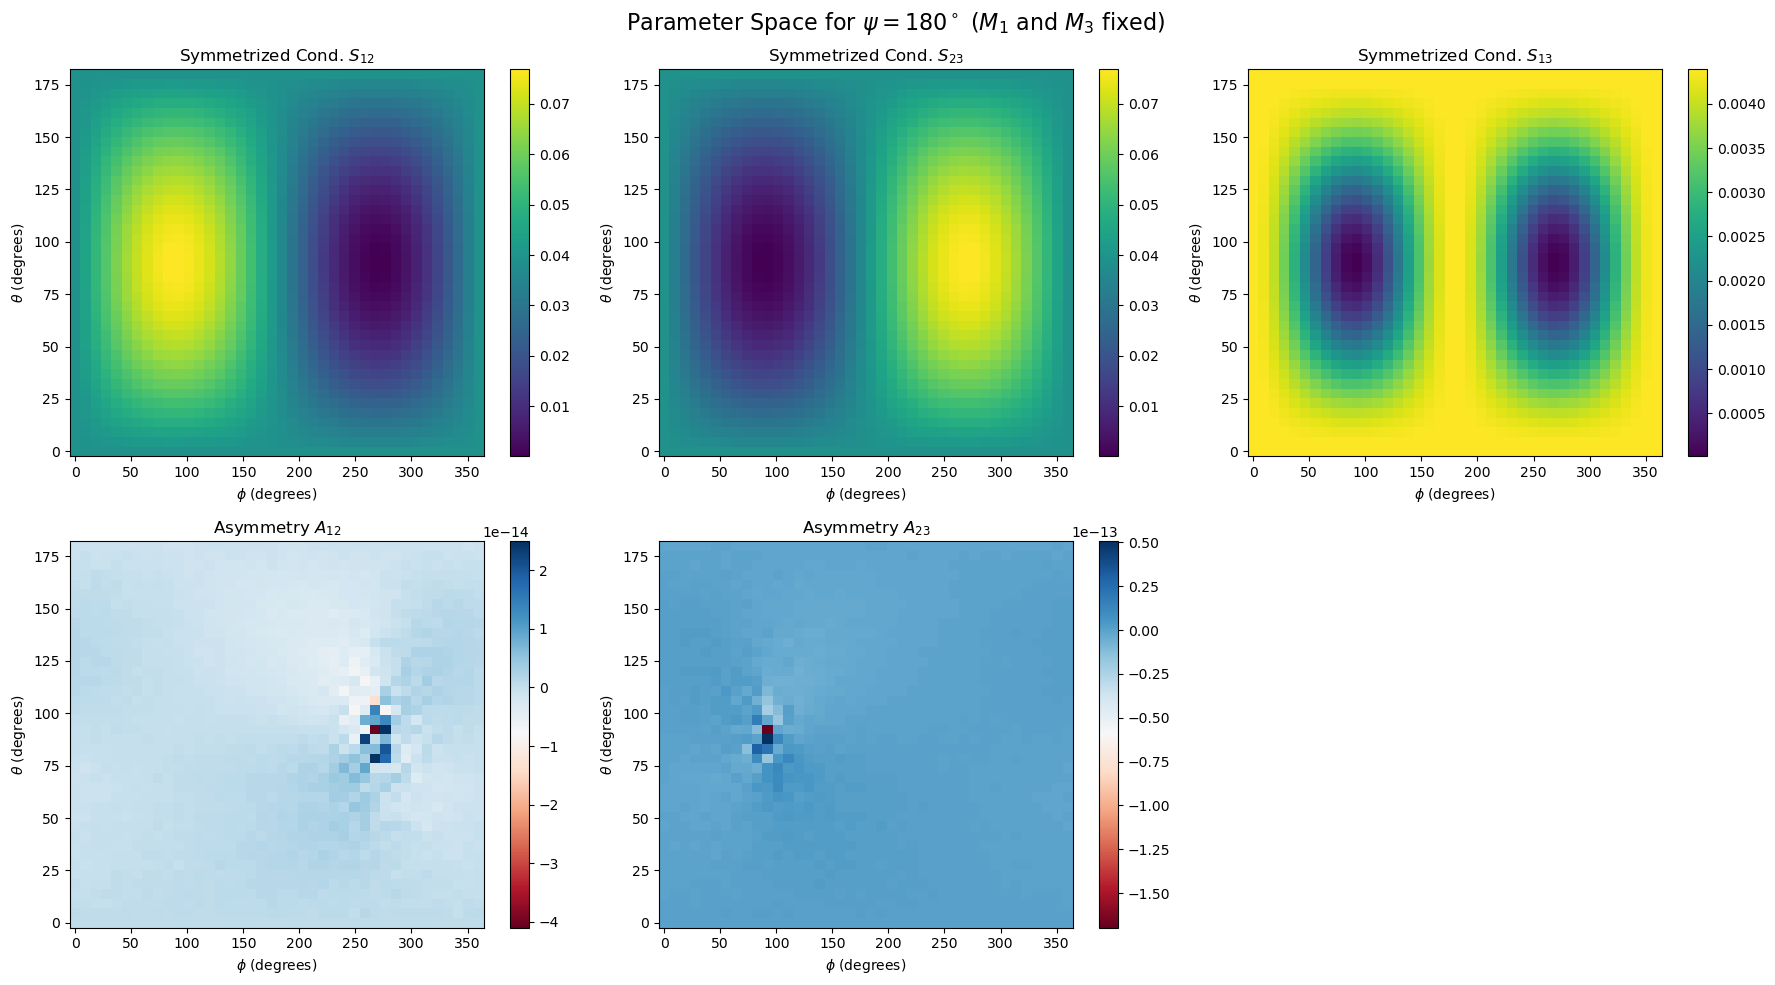

In [8]:
def generate_3param_colormaps(psi_deg):
    """
    Generates color maps for symmetrized conductances and asymmetries
    by sweeping phi and theta for a fixed psi.
    """
    #Params
    Gf = 0.5
    P = 1.0
    Rg = 0.0
    Ig = 1.0
    GFN = [Gf, P, Rg, Ig]

    # Inject parameters
    Setup.setConductance('CF1', GFN)
    Setup.setConductance('CF2', GFN)
    Setup.setConductance('CF3', GFN)

    # 2. Setup the sweep grids
    resolution = 40  # Increase to 60 or 80 for smoother plots, 40 is fast.
    phi_vals = np.linspace(0, 2 * np.pi, resolution)
    theta_vals = np.linspace(0, np.pi, resolution)

    # Create empty grids to store our data
    S12_grid = np.zeros((resolution, resolution))
    S23_grid = np.zeros((resolution, resolution))
    S13_grid = np.zeros((resolution, resolution))

    A12_grid = np.zeros((resolution, resolution))
    A23_grid = np.zeros((resolution, resolution))

    psi = np.radians(psi_deg)

    M1 = [np.sin(psi/2), 0, np.cos(psi/2)]
    M3 = [-np.sin(psi/2), 0, np.cos(psi/2)]
    Setup.setMagnetization('F1', 'T', M1)
    Setup.setMagnetization('F3', 'T', M3)

    # Loop for M2
    for i, theta in enumerate(theta_vals):
        for j, phi in enumerate(phi_vals):
            M2 = [np.sin(phi)*np.sin(theta), np.cos(phi)*np.sin(theta), np.cos(theta)]
            Setup.setMagnetization('F2', 'T', M2)

            Setup.compute()
            G_mat = Setup.ConductanceMatrix

            S12_grid[i, j] = (G_mat[2,3] + G_mat[3,2]) / 2.0
            S23_grid[i, j] = (G_mat[3,4] + G_mat[4,3]) / 2.0
            S13_grid[i, j] = (G_mat[2,4] + G_mat[4,2]) / 2.0

            # Asymmetries: A = (G_ij - G_ji) / (G_ij + G_ji)
            denom12 = G_mat[2,3] + G_mat[3,2]
            denom23 = G_mat[3,4] + G_mat[4,3]

            A12_grid[i, j] = (G_mat[2,3] - G_mat[3,2]) / denom12 if denom12 != 0 else 0
            A23_grid[i, j] = (G_mat[3,4] - G_mat[4,3]) / denom23 if denom23 != 0 else 0

    # 4. Plotting the grids
    Phi_mesh, Theta_mesh = np.meshgrid(np.degrees(phi_vals), np.degrees(theta_vals))

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Parameter Space for $\psi = {psi_deg}^\circ$ ($M_1$ and $M_3$ fixed)', fontsize=16)

    # Helper for repetitive pcolormesh calls
    def plot_map(ax, data, title, cmap_name):
        c = ax.pcolormesh(Phi_mesh, Theta_mesh, data, shading='auto', cmap=cmap_name)
        ax.set_title(title)
        ax.set_xlabel('$\phi$ (degrees)')
        ax.set_ylabel('$\\theta$ (degrees)')
        fig.colorbar(c, ax=ax)

    # Top Row: Symmetrized Conductances
    plot_map(axs[0, 0], S12_grid, 'Symmetrized Cond. $S_{12}$', 'viridis')
    plot_map(axs[0, 1], S23_grid, 'Symmetrized Cond. $S_{23}$', 'viridis')
    plot_map(axs[0, 2], S13_grid, 'Symmetrized Cond. $S_{13}$', 'viridis')

    # Bottom Row: Asymmetries
    plot_map(axs[1, 0], A12_grid, 'Asymmetry $A_{12}$', 'RdBu') # Diverging colormap for asymmetry
    plot_map(axs[1, 1], A23_grid, 'Asymmetry $A_{23}$', 'RdBu')

    # Leave the bottom right empty or plot A13
    axs[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the function for an opening angle of 90 degrees
generate_3param_colormaps(psi_deg=0)
generate_3param_colormaps(psi_deg=90)
generate_3param_colormaps(psi_deg=180)

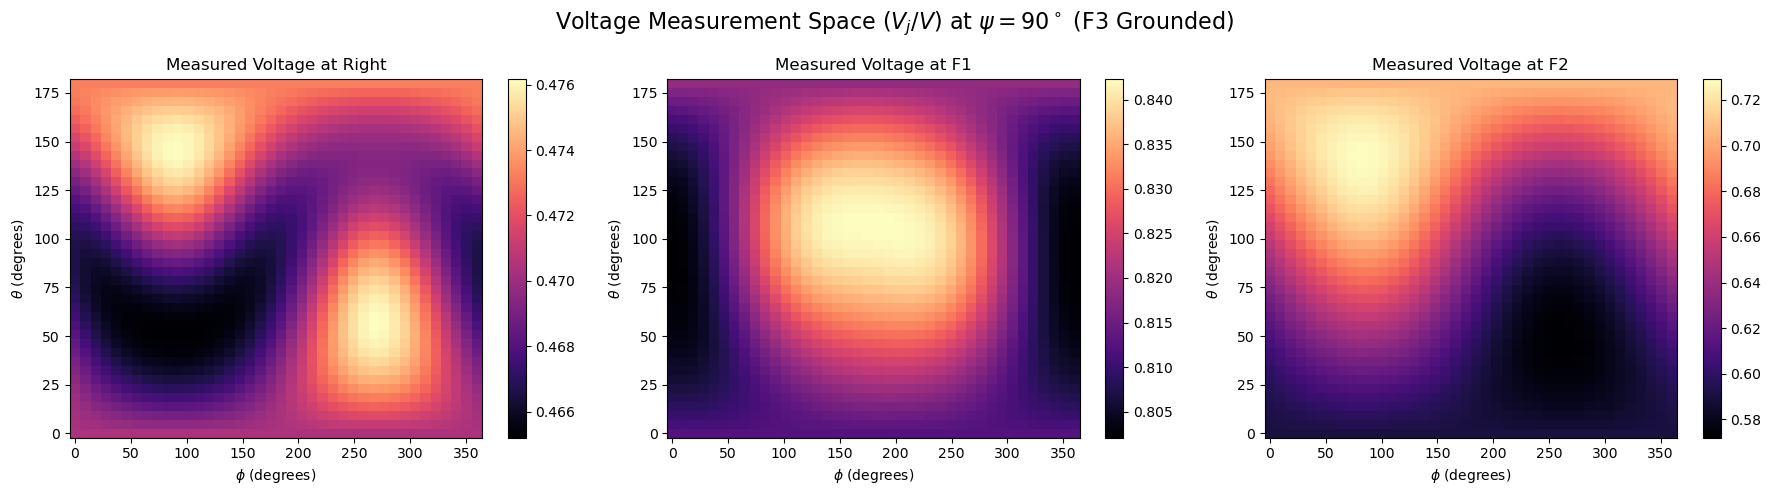

In [5]:
#Imports
import matplotlib.pyplot as plt

# Define Circuit Topology
def build_clean_topology():
    """Initializes, builds, and finalizes a fresh circuit instance."""
    global Setup
    Setup = SpintronicCircuit()

    # Add Normal and Ferro terminals
    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")
    Setup.addFerroTerminal("F1", magnetization=[1.0, 0.0, 0.0])
    Setup.addFerroTerminal("F2", magnetization=[0.0, 1.0, 0.0])
    Setup.addFerroTerminal("F3", magnetization=[0.0, 0.0, 1.0])

    # Add normal nodes
    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")

    # Define standard conductor parameters for part d
    Gn = 1.0
    GFN_init = [0.5, 1.0, 0.0, 1.0] # [Gf=0.5, P=1.0, Rg=0, Ig=1.0]

    # Add conductors
    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN_init)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN_init)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN_init)

    # Finalize allocates the matrix space internally
    Setup.finalize()

# ==========================================
# 2. HELPER: Compute Relative Voltages
# ==========================================
def compute_relative_voltages(psi, phi, theta):
    """Updates magnetizations and extracts current-biased voltages."""
    M1 = [np.sin(psi/2), 0, np.cos(psi/2)]
    M2 = [np.sin(phi)*np.sin(theta), np.cos(phi)*np.sin(theta), np.cos(theta)]
    M3 = [-np.sin(psi/2), 0, np.cos(psi/2)]

    Setup.setMagnetization('F1', 'T', M1)
    Setup.setMagnetization('F2', 'T', M2)
    Setup.setMagnetization('F3', 'T', M3)
    Setup.compute()

    # Get resistance matrix with F3 grounded [cite: 105]
    R_mat = Setup.resistanceMatrix(ground='F3')

    # Terminal indices based on addition order: Left(0), Right(1), F1(2), F2(3) [cite: 91]
    V_left_self = R_mat[0, 0]
    if V_left_self == 0:
        return 0, 0, 0

    # V_j / V_Left
    V_Right = R_mat[1, 0] / V_left_self
    V_F1 = R_mat[2, 0] / V_left_self
    V_F2 = R_mat[3, 0] / V_left_self

    return V_Right, V_F1, V_F2

# Main Sweep and Plot Generations
# ==========================================
def run_exercise_d_sweep(psi_deg):
    # First to build the hardware environment freshly
    build_clean_topology()

    # Now set up grid dimensions
    resolution = 40
    phi_vals = np.linspace(0, 2*np.pi, resolution)
    theta_vals = np.linspace(0, np.pi, resolution)

    V_Right_grid = np.zeros((resolution, resolution))
    V_F1_grid = np.zeros((resolution, resolution))
    V_F2_grid = np.zeros((resolution, resolution))

    psi = np.radians(psi_deg)

    # For loop to sweep the parameters
    for i, theta in enumerate(theta_vals):
        for j, phi in enumerate(phi_vals):
            vr, vf1, vf2 = compute_relative_voltages(psi, phi, theta)
            V_Right_grid[i, j] = vr
            V_F1_grid[i, j] = vf1
            V_F2_grid[i, j] = vf2

    # Visualizations below
    Phi_mesh, Theta_mesh = np.meshgrid(np.degrees(phi_vals), np.degrees(theta_vals))
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Voltage Measurement Space ($V_j / V$) at $\psi = {psi_deg}^\circ$ (F3 Grounded)', fontsize=16)

    c1 = axs[0].pcolormesh(Phi_mesh, Theta_mesh, V_Right_grid, shading='auto', cmap='magma')
    axs[0].set_title('Measured Voltage at Right')
    fig.colorbar(c1, ax=axs[0])

    c2 = axs[1].pcolormesh(Phi_mesh, Theta_mesh, V_F1_grid, shading='auto', cmap='magma')
    axs[1].set_title('Measured Voltage at F1')
    fig.colorbar(c2, ax=axs[1])

    c3 = axs[2].pcolormesh(Phi_mesh, Theta_mesh, V_F2_grid, shading='auto', cmap='magma')
    axs[2].set_title('Measured Voltage at F2')
    fig.colorbar(c3, ax=axs[2])

    for ax in axs:
        ax.set_xlabel('$\phi$ (degrees)')
        ax.set_ylabel('$\\theta$ (degrees)')

    plt.tight_layout()
    plt.show()

# Execute the complete block
run_exercise_d_sweep(psi_deg=90)

In [7]:
import numpy as np
from scipy.optimize import minimize
from spintronics import SpintronicCircuit

# Base Topology Setup
def build_base_topology():
    global Setup
    Setup = SpintronicCircuit()

    Setup.addNormalTerminal("Left")
    Setup.addNormalTerminal("Right")
    Setup.addFerroTerminal("F1")
    Setup.addFerroTerminal("F2")
    Setup.addFerroTerminal("F3")

    Setup.addNormalNode("N1")
    Setup.addNormalNode("N2")
    Setup.addNormalNode("N3")

    # Parameters given: G=1, GF=0.5, P=1.0, Rg=0, Ig=1.0
    Gn = 1.0
    GFN = [0.5, 1.0, 0.0, 1.0]

    Setup.addConductor("C0", 'NT', 'N1', 'Left', Gn)
    Setup.addConductor("C3", 'NT', 'N3', 'Right', Gn)
    Setup.addConductor("C1", 'NN', 'N1', 'N2', Gn)
    Setup.addConductor("C2", 'NN', 'N2', 'N3', Gn)

    Setup.addConductor('CF1', 'NT', 'N1', 'F1', GFN)
    Setup.addConductor('CF2', 'NT', 'N2', 'F2', GFN)
    Setup.addConductor('CF3', 'NT', 'N3', 'F3', GFN)
    Setup.finalize()

# Forward Problem Function
def get_voltages_from_angles(psi, phi, theta):
    """Computes relative voltages [V_Right/V, V_F1/V, V_F2/V] for given angles."""
    M1 = [np.sin(psi/2), 0, np.cos(psi/2)]
    M2 = [np.sin(phi)*np.sin(theta), np.cos(phi)*np.sin(theta), np.cos(theta)]
    M3 = [-np.sin(psi/2), 0, np.cos(psi/2)]

    Setup.setMagnetization('F1', 'T', M1)
    Setup.setMagnetization('F2', 'T', M2)
    Setup.setMagnetization('F3', 'T', M3)
    Setup.compute()

    # Below the resistanceMatrix to calculate network states for the specified terminal grounded
    R_mat = Setup.resistanceMatrix(ground='F3') #[cite: 105]
    V_left_self = R_mat[0, 0]

    #Quick 0 check
    if V_left_self == 0:
        return 0.0, 0.0, 0.0

    return R_mat[1, 0]/V_left_self, R_mat[2, 0]/V_left_self, R_mat[3, 0]/V_left_self

# =====================================================================
# (BONUS) Inverse Problem Solver!!
# =====================================================================
def invert_magnetization(v_right_meas, v_f1_meas, v_f2_meas, num_starts=5):
    """
    Takes 3 relative voltage measurements and reconstructs [psi, phi, theta] in degrees
    """

    # Define objective function (Residual Sum of Squares method)
    def objective_func(angles):
        psi, phi, theta = angles
        vr_calc, vf1_calc, vf2_calc = get_voltages_from_angles(psi, phi, theta)

        return (vr_calc - v_right_meas)**2 + \
               (vf1_calc - v_f1_meas)**2 + \
               (vf2_calc - v_f2_meas)**2

    # Bounded physical search constraints: psi, phi, theta
    bounds = ((0, 2*np.pi), (0, 2*np.pi), (0, np.pi))

    #Starting from inf
    best_score = float('inf')
    best_angles = None

    # Loop to go over local minima space
    for s in range(num_starts):
        if s == 0:
            # Starting guess is exactly at the center of the parameter space
            initial_guess = [np.pi, np.pi, np.pi/2]
        else:
            # Subsequent guesses are randomized across the bounds
            initial_guess = [np.random.uniform(0, 2*np.pi),
                             np.random.uniform(0, 2*np.pi),
                             np.random.uniform(0, np.pi)]

        res = minimize(objective_func, initial_guess, method='L-BFGS-B', bounds=bounds, tol=1e-8)

        if res.success and res.fun < best_score:
            best_score = res.fun
            best_angles = res.x

        # Break early if we hit an exact numerical match
        if best_score < 1e-12:
            break

    if best_angles is not None:
        return np.degrees(best_angles), best_score
    else:
        raise ValueError("The optimizer could not find a valid convergence point.")

# BELOW IS A WORKFLOW TO VERIFY OUR SYSTEM

# =====================================================================
############ 4. Verification Workflow  ################################
# =====================================================================
# Initialize the system topology once
build_base_topology()

# Define a hidden physical state we want to recover (in deg)
true_psi = 75.0
true_phi = 210.0
true_theta = 45.0

print(f"--- Target Setup Configuration ---")
print(f"True Angles -> Psi: {true_psi}°, Phi: {true_phi}°, Theta: {true_theta}°\n")

# Generate the mock "measured" inputs from the forward engine
v_r, v_f1, v_f2 = get_voltages_from_angles(np.radians(true_psi),
                                           np.radians(true_phi),
                                           np.radians(true_theta))

print(f"--- Generated Voltage Inputs ---")
print(f"V_Right/V: {v_r:.6f}")
print(f"V_F1/V:    {v_f1:.6f}")
print(f"V_F2/V:    {v_f2:.6f}\n")

# Run the inverse solver on those measurements
recovered_angles, final_error = invert_magnetization(v_r, v_f1, v_f2)

print(f"--- Inverse Optimization Results ---")
print(f"Recovered -> Psi: {recovered_angles[0]:.2f}°")
print(f"Recovered -> Phi: {recovered_angles[1]:.2f}°")
print(f"Recovered -> Theta: {recovered_angles[2]:.2f}°")
print(f"Residual Solver Error (SSE): {final_error:.2e}")

--- Target Setup Configuration ---
True Angles -> Psi: 75.0°, Phi: 210.0°, Theta: 45.0°

--- Generated Voltage Inputs ---
V_Right/V: 0.472585
V_F1/V:    0.820352
V_F2/V:    0.581806

--- Inverse Optimization Results ---
Recovered -> Psi: 258.47°
Recovered -> Phi: 258.61°
Recovered -> Theta: 158.19°
Residual Solver Error (SSE): 5.82e-10
